In [45]:
import importlib
import processing_fun
importlib.reload(processing_fun)
from utils import OperonArgs
import matplotlib.pyplot as plt
from os.path import join as pjoin
import numpy as np

# IOB Fits


Reading from configuration file: conf/iob_6.ini

Target: A

All model lengths:
[ 5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23 24 25 26 27 28
 29 30 32 34 36 37 38 39 40 41 42 43 45 46 47 48 49 50 52 54]

Equation requested:
(0.101915 + (0.981869 * (((((((18.352127 * X9) - ((-74.840126) * X1)) + (54.567383 * X2)) / (sqrt(1 + ((25.086458 * X9) - 9.698587) ^ 2))) / (sqrt(1 + (((4.385856 * X9) - 3.134392) ^ 2) ^ 2))) + ((-3.267232) * X1)) - ((((-3059.672607) * X8) - (((163.182144 * X1) + (596.445190 * X7)) - (-15.086555))) / exp(((3.152609 * X9) ^ 2))))))

Equation with pars
-3.207993816608*IOB1 - 0.981869*(-163.182144*IOB1 - 596.44519*IOB7 - 3059.672607*IOB8 - 15.086555)*exp(-9.938943506881*lam**2) + 0.101915 + 0.981869*(74.840126*IOB1 + 54.567383*IOB2 + 18.352127*lam)/(sqrt((4.385856*lam - 3.134392)**4 + 1)*sqrt((25.086458*lam - 9.698587)**2 + 1))

Converted equation:
-b0*IOB1 - b1*(-b2*IOB1 - b3*IOB7 - b4*IOB8 - b5)*exp(-b6*lam**2) + b7 + b8*(b9*IOB1 + b10*IOB2 + b11*lam)/(s

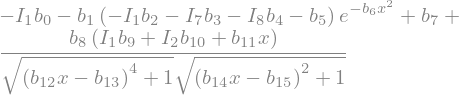


Latex version:
- I_{1} b_{0} - b_{1} \left(- I_{1} b_{2} - I_{7} b_{3} - I_{8} b_{4} - b_{5}\right) e^{- b_{6} x^{2}} + b_{7} + \frac{b_{8} \left(I_{1} b_{9} + I_{2} b_{10} + b_{11} x\right)}{\sqrt{\left(b_{12} x - b_{13}\right)^{4} + 1} \sqrt{\left(b_{14} x - b_{15}\right)^{2} + 1}}
-b0*IOB1 - b1*(-b2*IOB1 - b3*IOB7 - b4*IOB8 - b5)*exp(-b6*lam**2) + b7 + b8*(b9*IOB1 + b10*IOB2 + b11*lam)/(sqrt((b12*lam - b13)**4 + 1)*sqrt((b14*lam - b15)**2 + 1))

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
Reparameterising expression:
Original number of parameters: 20
Temporary global prefix: c, temporary local prefix: d
Old local parameters: ['IOB1', 'IOB2', 'IOB7', 'IOB8']
Final number of parameters: 10
Of which global: 7 and local: 3
Final values: [4.385856, 0.981869, -9.93894350688100, 25.086458, -3.13439200000000, -9.69858700000000, 18.3521

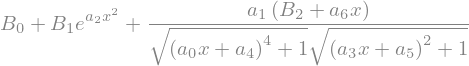

--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------


Reading from configuration file: conf/iob_6.ini

Target: A

Reading from configuration file: conf/iob_6.ini

Comparing to literature for train data...
Using Av column: A_5542A
Using 644 galaxies with Av low.


100%|██████████| 644/644 [00:00<00:00, 920.90it/s]


	Median Absolute Deviation of dF/F for 2-parameter fit on training data: 0.011266083355209733
	Median Absolute Deviation of dF/F for 4-parameter fit on training data: 0.008221665550225854
	Median Absolute Deviation of dF/F for SR fit on training data: 0.011281437143149886

Comparing to literature for val data...
Using Av column: A_5542A
Using 304 galaxies with Av low.


100%|██████████| 304/304 [00:00<00:00, 928.05it/s]


	Median Absolute Deviation of dF/F for 2-parameter fit on training data: 0.011609364998647065
	Median Absolute Deviation of dF/F for 4-parameter fit on training data: 0.00881963395083507
	Median Absolute Deviation of dF/F for SR fit on training data: 0.01160281797971241


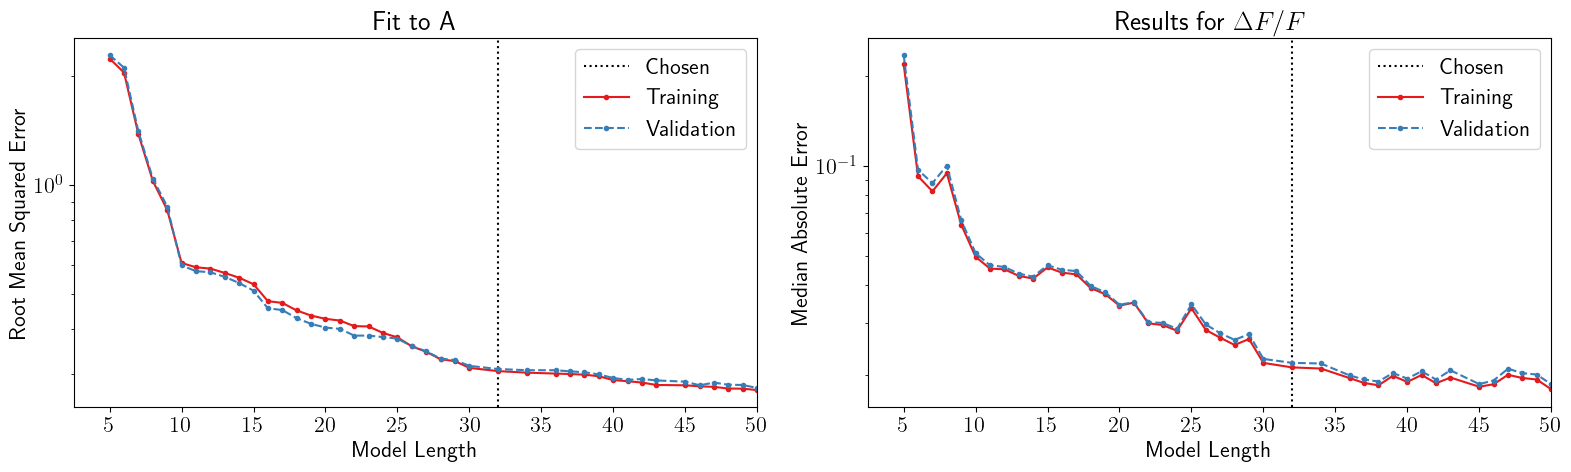

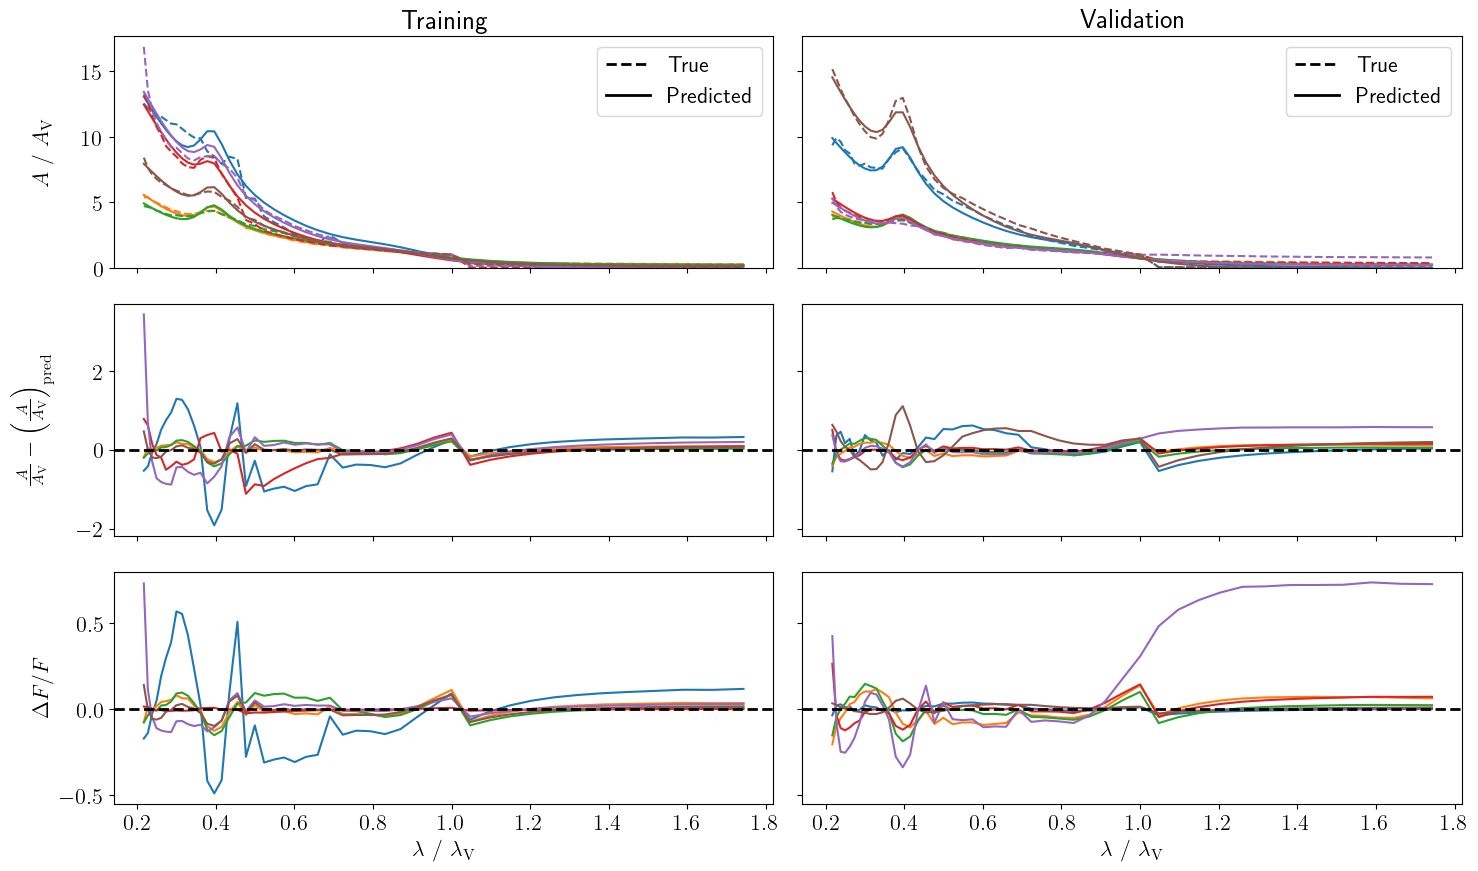

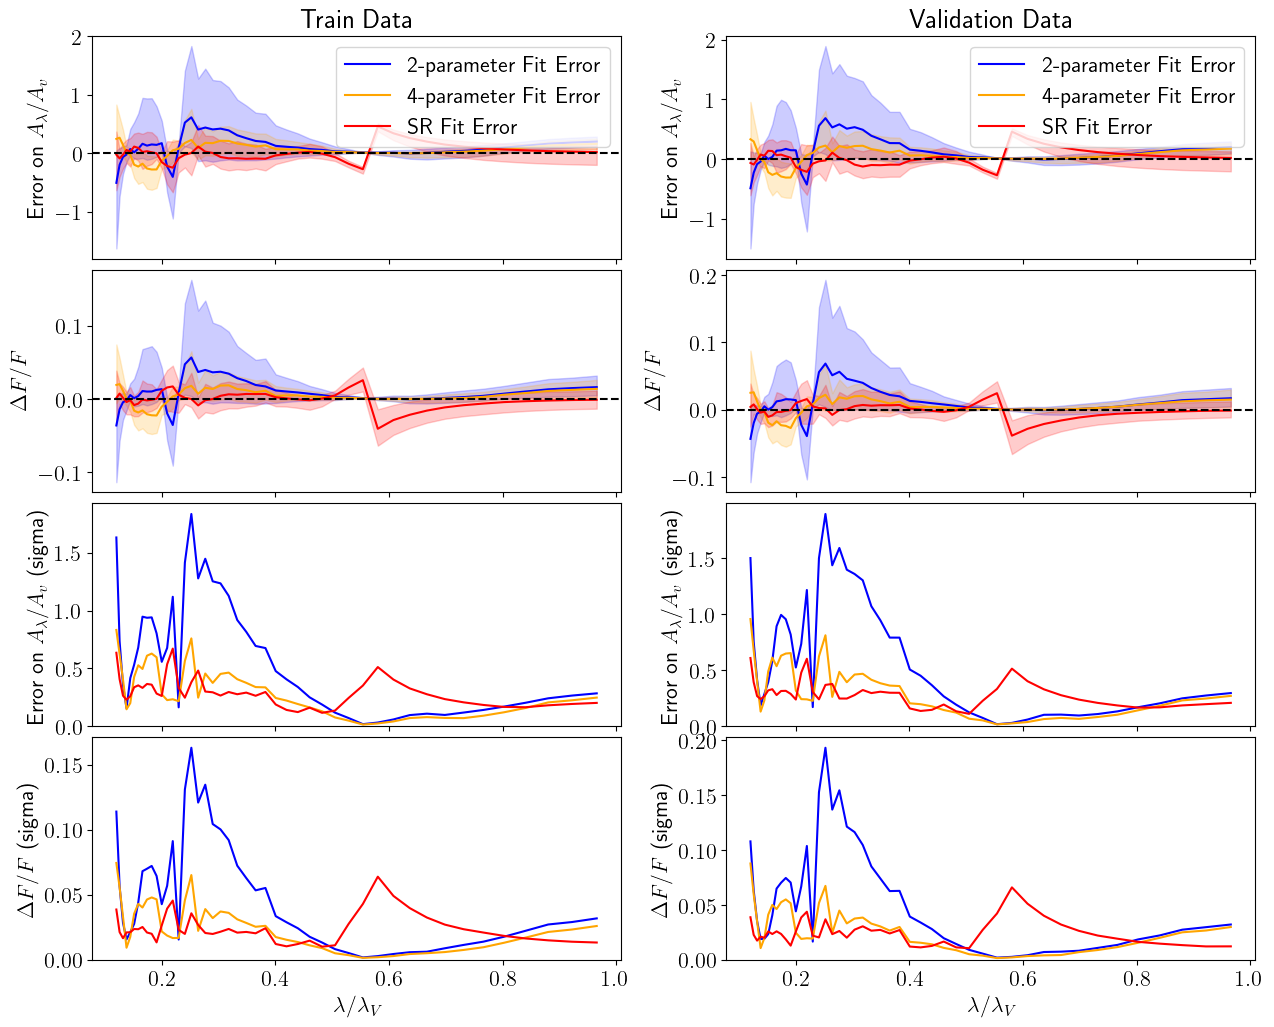

In [48]:
ini_file = 'conf/iob_1.ini'; ilen = 72
ini_file = 'conf/iob_2.ini'; ilen = 51
ini_file = 'conf/iob_3.ini'; ilen = 32
ini_file = 'conf/iob_4.ini'; ilen = 30
ini_file = 'conf/iob_6.ini'; ilen = 32 # quite simple -> rerunning as iob_10 with 24 hours
# ini_file = 'conf/iob_7.ini'; ilen = 27
# ini_file = 'conf/iob_8.ini'; ilen = 32 # not very good
# ini_file = 'conf/iob_9.ini'; ilen = 28
# ini_file = 'conf/iob_10.ini'; ilen = 34
ilen = 32
# ilen = None
processing_fun.plot_pareto(ini_file, ilen=ilen)
# processing_fun.prediction_plots(ini_file, ilen=ilen);
processing_fun.plot_example(ini_file, ilen=ilen, nexamples=6);
processing_fun.compare_to_literature(ini_file, ilen=ilen, which_gals='low');

# Check Distribution of Training and Validation Parameters


Reading from configuration file: conf/iob_0.ini
(46000, 7) (23000, 7)


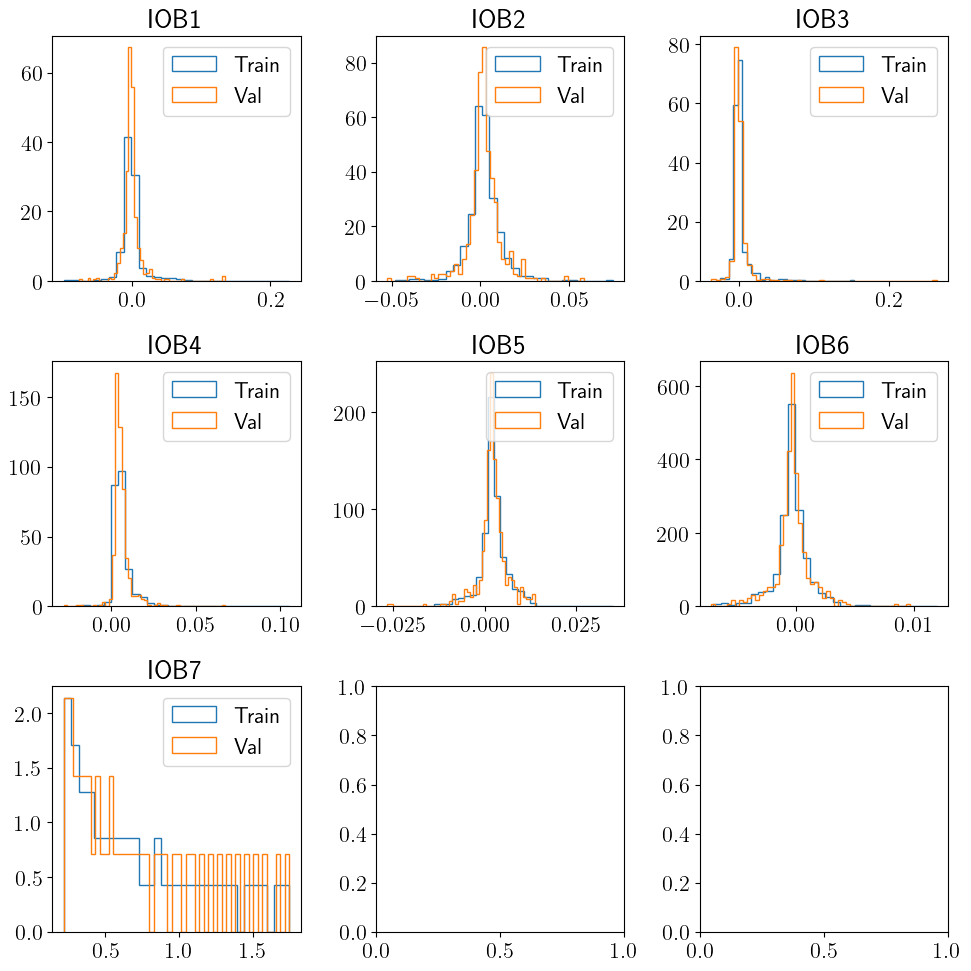

In [114]:
ini_file = 'conf/iob_0.ini'
args = OperonArgs(ini_file)
    
# Load training and validation data
dirname = pjoin(args.data_dir, f'{args.in_param}_data_{args.version_num}')
fname_train = pjoin(dirname, f'{args.in_param}_train_data.txt')
fname_val = pjoin(dirname, f'{args.in_param}_val_data.txt')

with open(fname_train, 'r') as f:
    names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_train, skiprows=1)
X = data[:,2:-1]
y = data[:,-1]

with open(fname_val, 'r') as f:
    val_names = f.readline().strip().split()[2:]
data = np.loadtxt(fname_val, skiprows=1)
Xval = data[:,2:-1]

print(X.shape, Xval.shape)

fig, axs = plt.subplots(3, 3, figsize=(10,10))
for i, ax in enumerate(axs.flatten()[:X.shape[1]]):
    ax.hist(X[:,i], bins=30, density=True, histtype='step', label='Train')
    ax.hist(Xval[:,i], bins=50, density=True, histtype='step', label='Val')
    ax.legend()
    ax.set_title(f'IOB{i+1}')
fig.tight_layout()